In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('global_cancer_patients_2015_2024.csv')
df.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [3]:
df.shape

(50000, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [5]:
df.describe()

,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.421540,2019.480520,5.001698,5.010126,5.010880,4.989826,4.991176,52467.298239,5.006462,4.951207
std,20.224451,2.871485,2.885773,2.888399,2.888769,2.881579,2.894504,27363.229379,2.883335,1.199677
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.050000,0.000000,0.900000
25%,37.000000,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,28686.225000,2.500000,4.120000
50%,54.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,52474.310000,5.000000,4.950000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76232.720000,7.500000,5.780000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000,9.160000


In [6]:
print('Number of duplicated rows: ', df.duplicated().sum())
print('Number of empty values: ')
print('\n')
print(df.isnull().sum())

Number of duplicated rows:  0
Number of empty values: 


Patient_ID               0
Age                      0
Gender                   0
Country_Region           0
Year                     0
Genetic_Risk             0
Air_Pollution            0
Alcohol_Use              0
Smoking                  0
Obesity_Level            0
Cancer_Type              0
Cancer_Stage             0
Treatment_Cost_USD       0
Survival_Years           0
Target_Severity_Score    0
dtype: int64


### **Data Vizualization**

We can see from the df.describe() above that the feature distribution is fully uniform. But for fun, let's visualizes it:

In [7]:
# styling Seaborn plots
def show():
    sns.despine()
    plt.show()

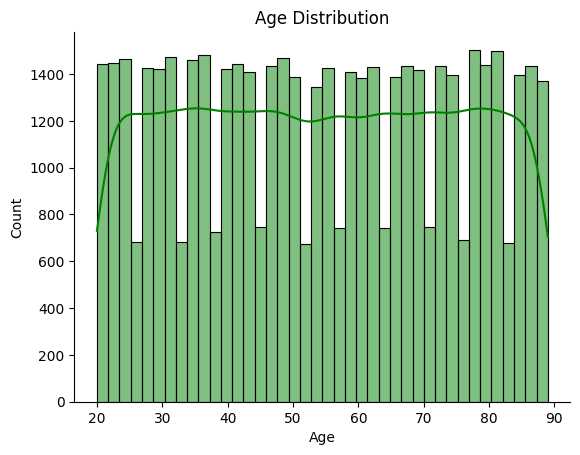

In [8]:
sns.histplot(df['Age'], kde=True, bins=40, color='green')
plt.title('Age Distribution')
show()

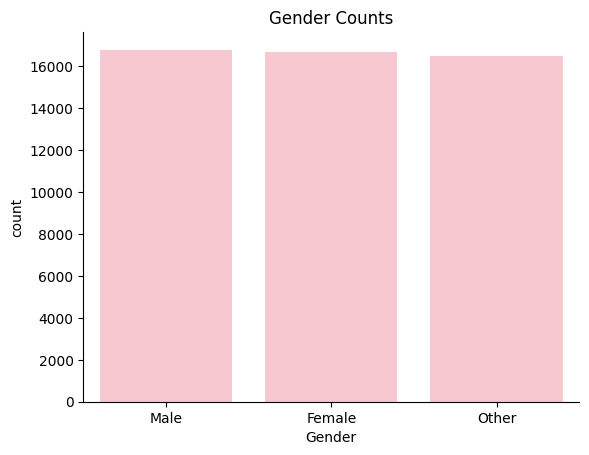

In [9]:
sns.countplot(data=df, x='Gender', color='pink')
plt.title('Gender Counts')
show()

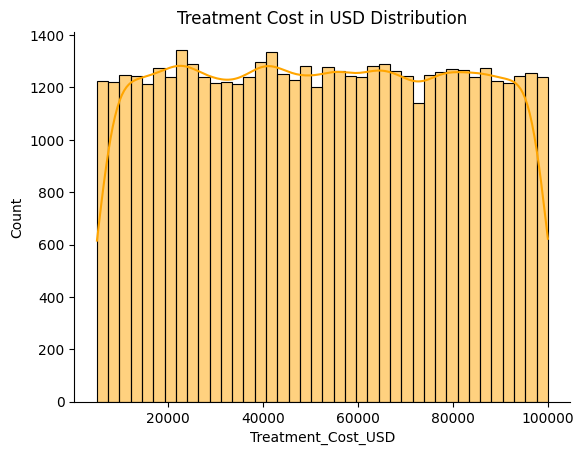

In [10]:
sns.histplot(df['Treatment_Cost_USD'], bins=40, kde=True, color='orange')
plt.title('Treatment Cost in USD Distribution')
show()

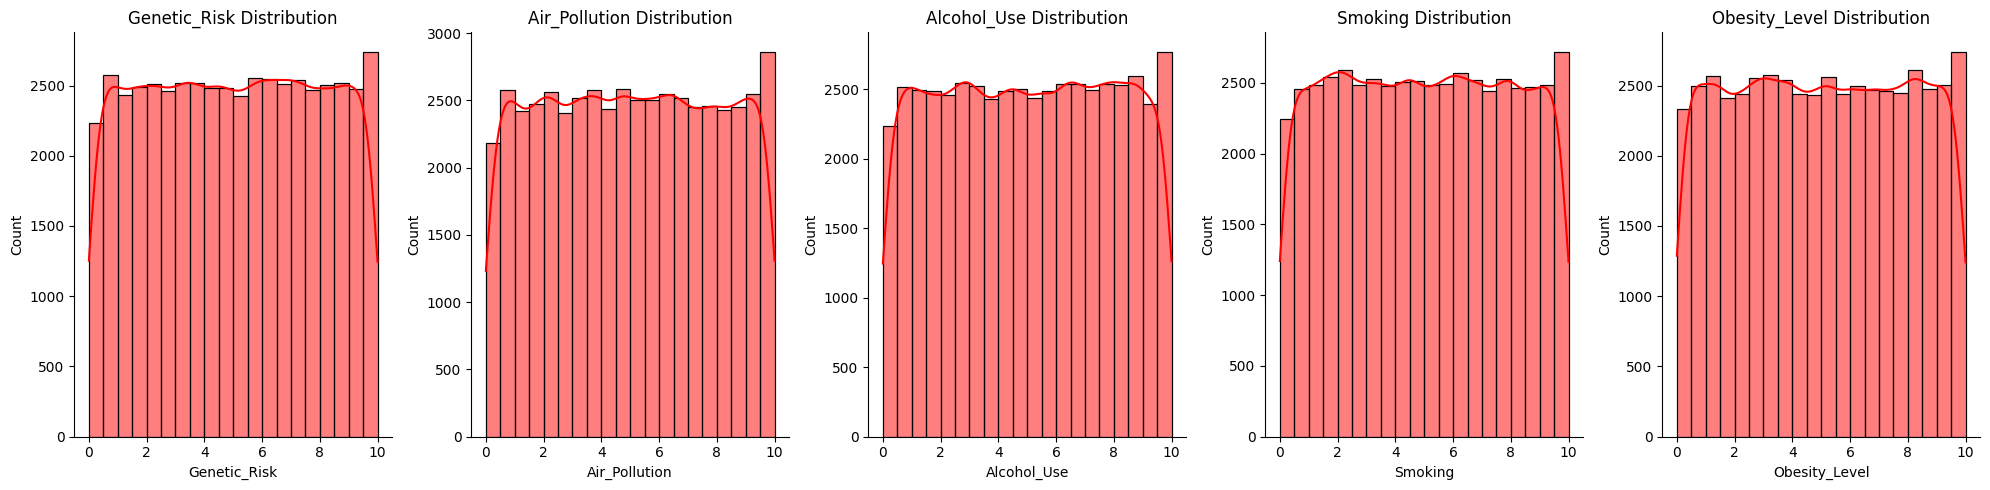

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(20,5))
columns = ['Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']

for i, ax in enumerate(axes):
    sns.histplot(df[columns[i]], bins=20, kde=True, color='red', ax=ax)
    ax.set_title(f'{columns[i]} Distribution')

plt.tight_layout()
show()

I think that's enough, as the other plots would look the same.

**How do these features affect the patients' survival score?**

<AxesSubplot: >

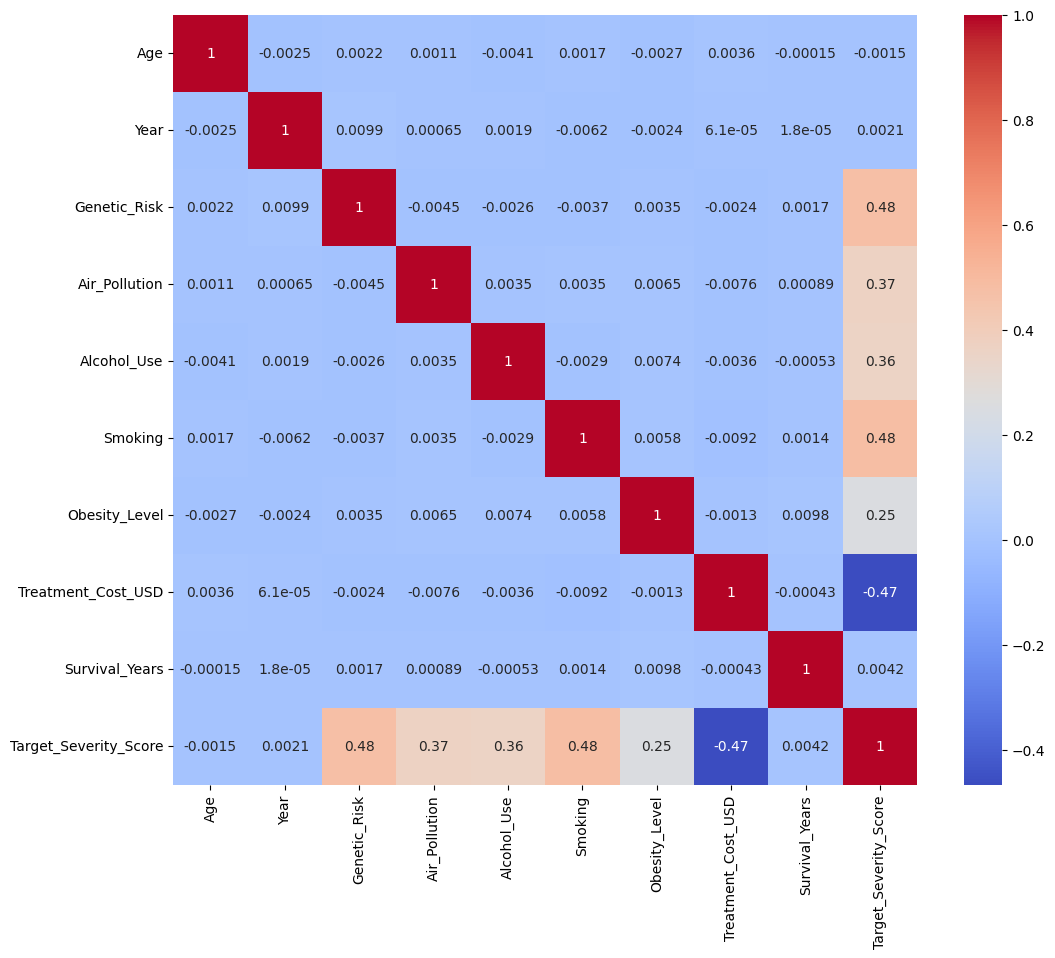

In [12]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

It seems that, among the numeric values, **genetic risk** and **smoking** have the greatest impact on the severity of cancer, along with **air pollution**, **aclcohol use**, and **obesity level**. **Age**, quite surprisingly, has a low affect. What I fing quite interesting is the negative correlation between **treatment cost in USD** and **target severity score**.

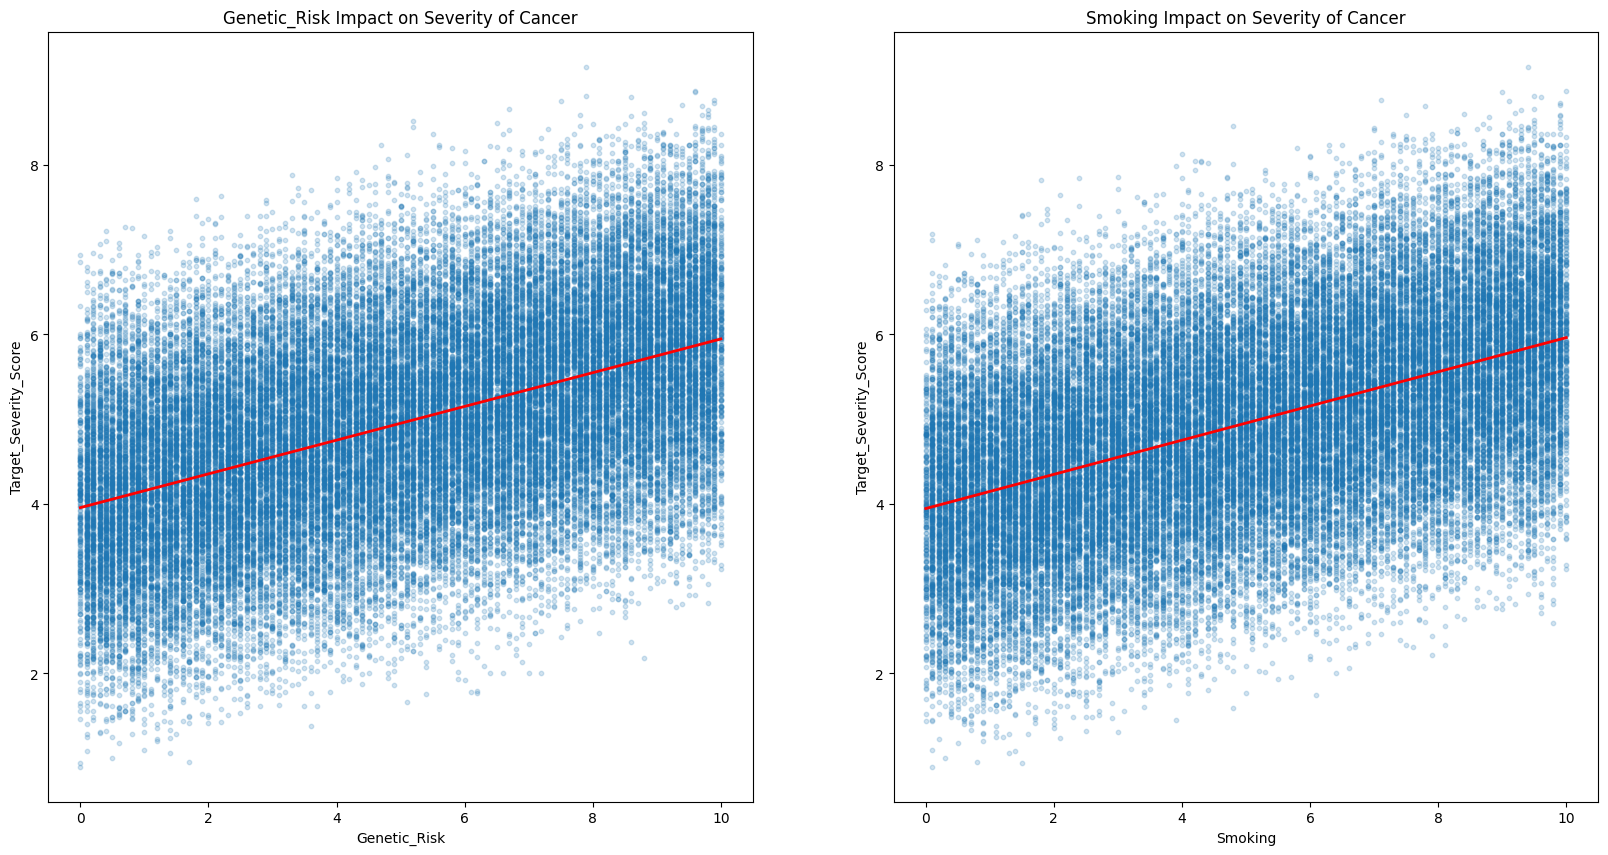

In [13]:
fig, axes = plt.subplots(1,2,figsize=(20,10))
columns = ['Genetic_Risk', 'Smoking']

for i, ax in enumerate(axes):
    sns.regplot(data=df, x=columns[i], y='Target_Severity_Score', scatter_kws={'s': 10, 'alpha': 0.2}, line_kws={'color': 'red', 'linewidth': 2}, ax=ax)
    ax.set_title(f'{columns[i]} Impact on Severity of Cancer')

plt.show()

I'll continue working on this project later, focusing on EDA notebooks for now.